<a href="https://colab.research.google.com/github/DevBatra05/PVR_Sem-6/blob/main/Exp-04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Google Colab Link :- https://colab.research.google.com/github/DevBatra05/PVR_Sem-6/blob/main/Exp-04.ipynb#scrollTo=R62YBtjbXoUl

# Experiment No. 4
## Un-Supervised Learning — K-Means Clustering and the Elbow Rule

---

### Aim
To implement the **K-Means Clustering algorithm from scratch** using NumPy, determine the optimal number of clusters using the **Elbow Rule**, and visualize the final clustering result along with the cost convergence curve.

---

### Theory

#### What is Unsupervised Learning?
In supervised learning, every data point has a label (like Class 0 or Class 1). In **unsupervised learning**, we have no labels at all — only raw input data X.

The goal is to find **hidden structure or groupings** in the data on its own. K-Means Clustering is one of the most widely used unsupervised learning algorithms.

---

#### What is K-Means Clustering?
K-Means partitions a dataset into **K groups (clusters)** such that:
- Points within the same cluster are as **similar (close) to each other** as possible
- Points in different clusters are as **far apart** as possible

Similarity is measured using **Euclidean Distance**:

**d(a, b) = sqrt( (a1 - b1)^2 + (a2 - b2)^2 )**

---

#### How does K-Means work? (Algorithm Steps)

**Step 1 — Initialize:** Randomly select K points from the data as initial centroids.

**Step 2 — Assign:** For each data point, compute its distance to every centroid. Assign the point to the cluster of the nearest centroid.

**Step 3 — Update:** Recompute each centroid as the mean of all points assigned to it.

**Step 4 — Repeat:** Repeat Steps 2 and 3 until the centroids stop changing significantly (convergence).

---

#### Cost Function (Inertia / Within-Cluster Sum of Squares)
The cost function measures how compact the clusters are:

**J = sum over all clusters k [ sum over all points in cluster k [ ||x - centroid_k||^2 ] ]**

Lower cost = tighter, more compact clusters.

---

#### The Elbow Rule
K-Means requires us to choose K in advance. But how do we know the right K?

We use the **Elbow Method**:
1. Run K-Means for K = 1, 2, 3, ..., 9
2. Record the cost (J) for each K
3. Plot K vs. Cost
4. The plot looks like an arm — the **elbow point** (where cost stops dropping sharply) is the optimal K

Beyond the elbow, adding more clusters gives diminishing returns — the model starts overfitting the data.

In [ ]:
# Import required libraries
import numpy as np               # For numerical computations and array operations
import pandas as pd              # For organizing data in a DataFrame
import matplotlib.pyplot as plt  # For plotting clustering results and cost curves

print("Libraries imported successfully!")

Libraries imported successfully!


---
### Step 1: Generate Dataset

We create a synthetic dataset with **3 natural clusters**:
- Cluster 1: 50 points centered at (2, 2)
- Cluster 2: 50 points centered at (6, 6)
- Cluster 3: 50 points centered at (2, 6)

Since this is unsupervised learning, we do NOT use the cluster labels during training. The algorithm must discover these groups on its own.

In [ ]:
np.random.seed(42)

# Cluster 1: 50 points around (2, 2)
c1 = np.random.randn(50, 2) * 1.2 + [2, 2]

# Cluster 2: 50 points around (6, 6)
c2 = np.random.randn(50, 2) * 1.2 + [6, 6]

# Cluster 3: 50 points around (2, 6)
c3 = np.random.randn(50, 2) * 1.2 + [2, 6]

# Stack all clusters into one dataset — no labels used
X = np.vstack((c1, c2, c3))

# Store in a DataFrame for easy viewing
data = pd.DataFrame(X, columns=["x1", "x2"])

print("Dataset shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())

Dataset shape: (150, 2)

First 5 rows:
         x1        x2
0  2.596057  1.834083
1  2.777226  3.827636
2  1.719016  1.719036
3  3.895055  2.920922
4  1.436631  2.651072


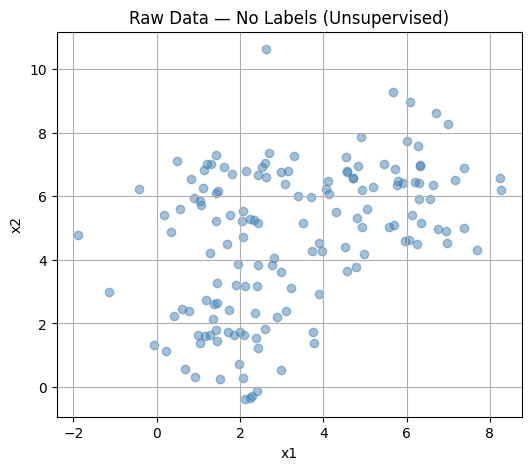

In [ ]:
# Visualize the raw data before clustering
# Since this is unsupervised, all points are shown in the same color
plt.figure(figsize=(6, 5))

plt.scatter(X[:, 0], X[:, 1], color='steelblue', alpha=0.5)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Raw Data — No Labels (Unsupervised)")
plt.grid(True)
plt.show()

---
### Step 2: Elbow Method — Finding the Optimal K

We run K-Means for each value of K from 1 to 9, record the final cost, and plot it.

The cost always decreases as K increases (more clusters = more flexibility). But at the **elbow point**, the rate of decrease slows down sharply — that is the optimal K.

For our data (which has 3 true clusters), the elbow should appear at **K = 3**.

In [ ]:
# Elbow Method: run K-Means for K = 1 to 9 and record cost for each K
k_values   = range(1, 10)
cost_values = []

for k in k_values:

    m = X.shape[0]   # total number of data points

    # Randomly pick k points from data as initial centroids
    indices   = np.random.choice(m, k, replace=False)
    centroids = X[indices]

    iterations = 50   # fixed iterations for the elbow scan

    for i in range(iterations):

        # --- Step 1: Compute distance from every point to every centroid ---
        distances = np.zeros((m, k))

        for j in range(k):
            # Euclidean distance from each point to centroid j
            distances[:, j] = np.sqrt(np.sum((X - centroids[j])**2, axis=1))

        # --- Step 2: Assign each point to the nearest centroid ---
        labels = np.argmin(distances, axis=1)

        # --- Step 3: Update centroids as mean of assigned points ---
        new_centroids = np.zeros_like(centroids)

        for j in range(k):
            points = X[labels == j]
            if len(points) > 0:
                new_centroids[j] = np.mean(points, axis=0)

        centroids = new_centroids

    # Compute final cost (Within-Cluster Sum of Squares) for this K
    J = 0
    for j in range(k):
        points = X[labels == j]
        J += np.sum((points - centroids[j])**2)

    cost_values.append(J)

print("Cost for each K:")
for k, c in zip(k_values, cost_values):
    print(f"  K = {k}  ->  Cost = {round(c, 2)}")

Cost for each K:
  K = 1  ->  Cost = 1499.49
  K = 2  ->  Cost = 728.12
  K = 3  ->  Cost = 385.58
  K = 4  ->  Cost = 344.99
  K = 5  ->  Cost = 284.71
  K = 6  ->  Cost = 226.54
  K = 7  ->  Cost = 222.86
  K = 8  ->  Cost = 174.08
  K = 9  ->  Cost = 158.05


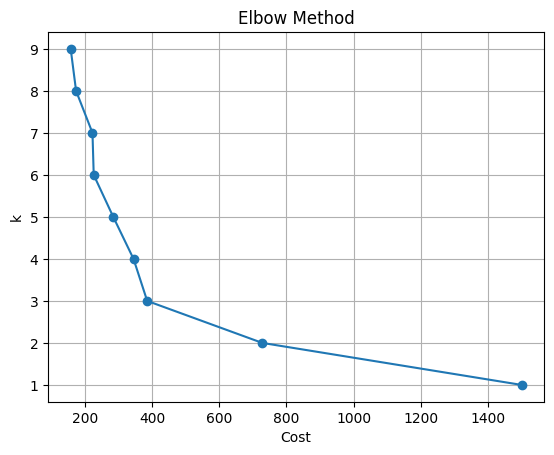

In [ ]:
# Plot the Elbow curve: Cost on x-axis, K on y-axis
plt.plot(cost_values, k_values, marker='o')

plt.xlabel("Cost")
plt.ylabel("k")
plt.title("Elbow Method")
plt.grid()
plt.show()

---
### Step 3: Train K-Means with Optimal K = 3

From the Elbow curve, the optimal number of clusters is **K = 3**.

We now run K-Means properly with:
- K = 3
- Up to 100 iterations
- Early stopping if cost change between iterations is less than tolerance (1e-4)

At each iteration the algorithm:
1. Assigns every point to the nearest centroid
2. Recomputes centroids as the mean of their assigned points
3. Checks if the cost has converged

In [ ]:
k = 3           # optimal number of clusters from elbow method
m = X.shape[0]  # total number of data points

# Randomly initialize k centroids from the data
indices   = np.random.choice(m, k, replace=False)
centroids = X[indices]

cost       = []     # track cost at each iteration
iterations = 100    # maximum number of iterations
tolerance  = 1e-4   # early stopping: stop if cost barely changes

for i in range(iterations):

    # --- Step 1: Compute Euclidean distance from every point to every centroid ---
    distances = np.zeros((m, k))

    for j in range(k):
        distances[:, j] = np.sqrt(np.sum((X - centroids[j])**2, axis=1))

    # --- Step 2: Assign each point to its nearest centroid ---
    labels = np.argmin(distances, axis=1)

    # --- Step 3: Recompute centroids as mean of assigned points ---
    new_centroids = np.zeros_like(centroids)

    for j in range(k):
        points = X[labels == j]
        if len(points) > 0:
            new_centroids[j] = np.mean(points, axis=0)

    # --- Step 4: Compute cost (Within-Cluster Sum of Squares) ---
    J = 0
    for j in range(k):
        points = X[labels == j]
        J += np.sum((points - centroids[j])**2)

    cost.append(J)

    # --- Early Stopping: stop if cost change is negligible ---
    if i > 0 and abs(cost[i] - cost[i-1]) < tolerance:
        print("Stopped at iteration", i)
        break

    # Update centroids for next iteration
    centroids = new_centroids

    if i % 10 == 0:
        print("Iteration", i, "Cost =", round(J, 2))

print("Centroids:\n", centroids)

Iteration 0 Cost = 576.41
Stopped at iteration 4
Centroids:
 [[5.66275112 6.02381993]
 [1.86810045 1.91041926]
 [1.71486923 6.17216441]]


---
### Step 4: Visualize the Clusters

After training, each point has been assigned a cluster label (0, 1, or 2). We plot each cluster in a different color, and mark the final centroids with an "X" symbol.

The centroid is the geometric center of its cluster — the algorithm converges when centroids stop moving.

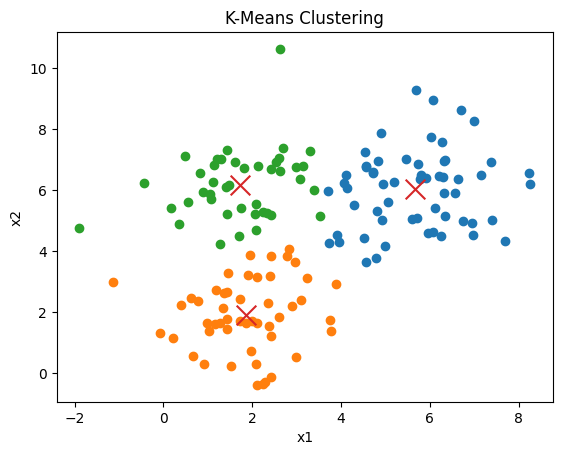

In [ ]:
plt.figure()

# Plot each cluster in a different color
for j in range(k):
    plt.scatter(X[labels == j, 0], X[labels == j, 1])

# Plot centroids with a large 'x' marker to distinguish them
plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=200)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("K-Means Clustering")

plt.show()

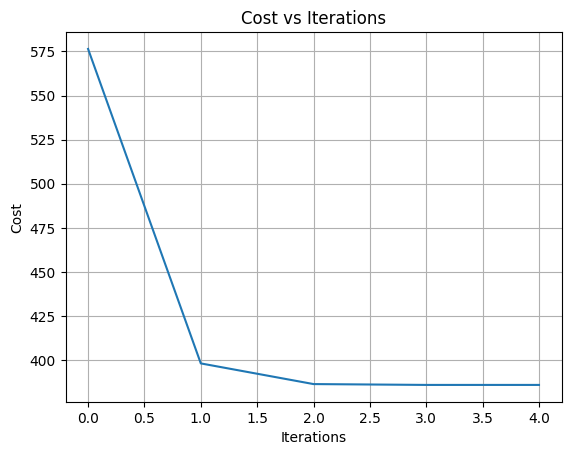

In [ ]:
# Plot cost over iterations to verify the algorithm converged
plt.plot(cost)

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")

plt.grid()
plt.show()

---
### Conclusion

In this experiment, we:

1. Generated a synthetic dataset with 3 natural clusters and no labels — a purely unsupervised setting.

2. Applied the **Elbow Method** by running K-Means for K = 1 to 9 and plotting the cost. The elbow appeared at K = 3, confirming the true number of clusters.

3. Trained **K-Means Clustering from scratch** with K = 3 using:
   - Random centroid initialization
   - Euclidean distance for assignment
   - Mean recomputation for centroid update
   - Early stopping based on cost tolerance

4. Visualized the final clusters and centroid positions.

5. Plotted the **Cost vs. Iterations** curve, confirming the algorithm converged to a stable solution.

Key Insight: K-Means is sensitive to initial centroid placement. Running it multiple times with different initializations and picking the run with the lowest final cost is a common practice in real applications.